In [12]:
%reload_ext autoreload
%autoreload 2

The history saving thread hit an unexpected error (DatabaseError('database disk image is malformed')).History will not be written to the database.


In [13]:
from functools import partial

import matplotlib.pyplot as plt
import seaborn as sns

from tabpfn_sbi.utils import (
    multi_plot,
    plot_metric_by_num_simulations,
    plot_calibration_curves,
    query,
    use_style,
)
from tabpfn_sbi.utils.plot_utils import DEFAULT_COLORS

In [14]:
import pandas as pd

df = pd.read_csv("../../results/sbibm_newtasks/summary.csv")
values = df["value"].apply(lambda x: eval(x))

In [15]:
# new_values = []
# for val in values:
#     if isinstance(val, float):
#         new_values.append([val])
#     else:
#         new_values.append(val)

# df["value"] = new_values

In [16]:
# df.to_csv("../../results/sbibm_newtasks/summary.csv", index=False)

In [17]:
name = "../../results/sbibm_newtasks"
query(name, metric="nll").head(10)

(metric=='nll')


/weka/macke/mgloeckler90/tabpfn_sbi/tabpfn_sbi/utils/data_utils.py:267: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["value"] = df.apply(


,method,estimator,embedding_net,task,num_simulations,seed,model_id,observation_ids,metric,value,time_train,time_eval,cfg
0,npe,nsf,none,weinberg,100,0,cab215c3-cdd5-4a82-81cc-25b02374d940,[-1],nll,0.042183,0.905605,NaN,"{'name': 'sbibm_newtasks', 'seed': 0, 'model_i..."
2,npe,nsf,none,weinberg,1000,1,319f7bb8-1285-41f3-a4ed-9e7be3ad20b8,[-1],nll,0.006269,4.162444,NaN,"{'name': 'sbibm_newtasks', 'seed': 1, 'model_i..."
4,npe,nsf,none,weinberg,10000,1,600a6b53-e467-4e87-b743-b03154e19b86,[-1],nll,0.010707,34.755799,NaN,"{'name': 'sbibm_newtasks', 'seed': 1, 'model_i..."
6,npe,nsf,none,weinberg,1000,0,b0583589-6cc6-42f0-a73e-f2b6599fb032,[-1],nll,0.045957,8.571440,NaN,"{'name': 'sbibm_newtasks', 'seed': 0, 'model_i..."
8,npe,nsf,none,weinberg,100,1,3f0abc05-b577-467f-bae8-fc162e1a4d86,[-1],nll,0.172794,0.889712,NaN,"{'name': 'sbibm_newtasks', 'seed': 1, 'model_i..."
10,npe,nsf,none,weinberg,10000,0,cd045d2f-217c-4bda-b09a-293dcb406e2d,[-1],nll,0.007926,59.899447,NaN,"{'name': 'sbibm_newtasks', 'seed': 0, 'model_i..."
12,npe,nsf,none,weinberg,100000,1,965d93dc-3621-4f0a-a4ea-a34c381ec666,[-1],nll,0.001029,192.754676,NaN,"{'name': 'sbibm_newtasks', 'seed': 1, 'model_i..."
14,npe,nsf,none,weinberg,100000,0,1089c1d9-c8f4-4df1-9754-6bdddff5585b,[-1],nll,0.001940,228.550447,NaN,"{'name': 'sbibm_newtasks', 'seed': 0, 'model_i..."
16,npe,nsf,none,biomolecular_docking,1000,0,a6684303-6c38-48db-8559-6bb2a1d2929e,[-1],nll,-0.784803,7.157936,NaN,"{'name': 'sbibm_newtasks', 'seed': 0, 'model_i..."
18,npe,nsf,none,biomolecular_docking,10000,0,c70ecfb4-6614-4a16-a321-ed9c233187ae,[-1],nll,-1.271484,70.005041,NaN,"{'name': 'sbibm_newtasks', 'seed': 0, 'model_i..."


In [47]:
df = query(
    "../../main_results/sbibm_newtasks",
    metric="nll",
    method=methods,
    num_simulations=100000,
)

(method=='npe'|method=='filtered_tabpfn') & (num_simulations==100000) & (metric=='nll')


/weka/macke/mgloeckler90/tabpfn_sbi/tabpfn_sbi/utils/data_utils.py:267: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["value"] = df.apply(


In [48]:
df_sub = df[["task", "method", "value"]]

In [49]:
df_sub.groupby(["method", "task"]).mean().loc["npe"]

,value
task,
biomolecular_docking,-1.580628
mg1,-1.456930
nonlinear_gaussian_tree,2.089931
nonlinear_marcov_chain,9.986876
nonlinear_marcov_chain_long,56.791084
weinberg,0.001423


In [50]:
df_sub.groupby(["method", "task"]).std().loc["npe"]

,value
task,
biomolecular_docking,0.047897
mg1,0.489563
nonlinear_gaussian_tree,0.068770
nonlinear_marcov_chain,0.074196
nonlinear_marcov_chain_long,0.326802
weinberg,0.001036


In [51]:
df_sub.groupby(["method", "task"]).mean().loc["filtered_tabpfn"]

,value
task,
biomolecular_docking,-0.593323
mg1,-2.235783
nonlinear_gaussian_tree,2.091716
nonlinear_marcov_chain,10.067458
weinberg,0.017129


In [52]:
df_sub.groupby(["method", "task"]).std().loc["filtered_tabpfn"]

,value
task,
biomolecular_docking,0.142459
mg1,0.101028
nonlinear_gaussian_tree,0.046282
nonlinear_marcov_chain,0.042267
weinberg,0.003277


In [ ]:
df = query(
    "../../main_results/sbibm_newtasks",
    metric="nll",
    task=tasks,
    method=methods,
    num_simulations=1000,
)
df_sub = df[["task", "method", "value"]]
df_sub.groupby(["method", "task"]).mean()

(method=='npe'|method=='filtered_tabpfn') & (task=='weinberg'|task=='nonlinear_gaussian_tree'|task=='streams'|task=='nonlinear_marcov_chain'|task=='mg1') & (num_simulations==1000) & (metric=='nll')


/weka/macke/mgloeckler90/tabpfn_sbi/tabpfn_sbi/utils/data_utils.py:267: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["value"] = df.apply(


(method=='npe'|method=='filtered_tabpfn') & (task=='weinberg'|task=='nonlinear_gaussian_tree'|task=='streams'|task=='nonlinear_marcov_chain'|task=='mg1') & (metric=='nll')
1.4
(7.0, 1.4)
(method=='npe'|method=='filtered_tabpfn') & (task=='weinberg') & (metric=='nll')
weinberg
(method=='npe'|method=='filtered_tabpfn') & (task=='streams') & (metric=='nll')


/weka/macke/mgloeckler90/tabpfn_sbi/tabpfn_sbi/utils/data_utils.py:267: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["value"] = df.apply(
/weka/macke/mgloeckler90/tabpfn_sbi/tabpfn_sbi/utils/data_utils.py:267: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["value"] = df.apply(
/weka/macke/mgloeckler90/tabpfn_sbi/tabpfn_sbi/utils/plot_utils.py:217: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
/weka/

streams
(method=='npe'|method=='filtered_tabpfn') & (task=='nonlinear_gaussian_tree') & (metric=='nll')
nonlinear_gaussian_tree
(method=='npe'|method=='filtered_tabpfn') & (task=='nonlinear_marcov_chain') & (metric=='nll')
nonlinear_marcov_chain


/weka/macke/mgloeckler90/tabpfn_sbi/tabpfn_sbi/utils/data_utils.py:267: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["value"] = df.apply(
/weka/macke/mgloeckler90/tabpfn_sbi/tabpfn_sbi/utils/plot_utils.py:217: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
/weka/macke/mgloeckler90/tabpfn_sbi/tabpfn_sbi/utils/data_utils.py:267: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["value"] = df.apply(
/weka/

(method=='npe'|method=='filtered_tabpfn') & (task=='mg1') & (metric=='nll')
mg1
npe
filtered_tabpfn



/weka/macke/mgloeckler90/tabpfn_sbi/tabpfn_sbi/utils/plot_utils.py:217: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


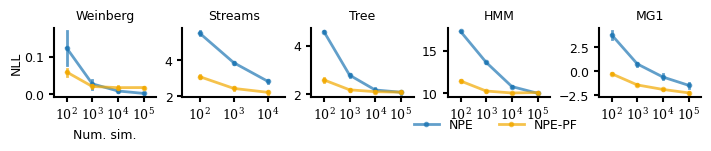

In [9]:
# tasks=["gaussian_mixture", "two_moons", "slcp", "gaussian_linear", "gaussian_linear_uniform", "gaussian_linear", "sir", "bernoulli_glm", "bernoulli_glm_raw", "lotka_volterra"]

methods = ["npe", "filtered_tabpfn"]
tasks = [
    "weinberg",
    "nonlinear_gaussian_tree",
    "streams",
    "nonlinear_marcov_chain",
    "mg1",
]

with use_style("pyloric"):
    fig, axes = multi_plot(
        "../../main_results/sbibm_newtasks",
        "task",
        "metric",
        partial(plot_metric_by_num_simulations, hue="method"),
        verbose=False,
        metric="nll",
        task=tasks,
        method=methods,
        figsize_per_col=1.4,
        figsize_per_row=1.4,
        color_map=DEFAULT_COLORS,
        hue="method",
        # y_lims=(0.5, 1.03),
        legend_bbox_to_anchor=(0.7, 0.02),
    )

    axes[0, 0].set_ylabel("NLL", x=-0.3)

    for ax in axes[0, 1:]:
        pass
        # ax.set_yticklabels([])
        # ax.set_xticklabels([])

    axes[0, 0].set_xlabel("Num. sim.")
    for ax in axes[0, 1:]:
        ax.set_xlabel("")

    # fig.savefig("fig2_amortized.svg", bbox_inches="tight", transparent=True)

(method=='npe'|method=='filtered_tabpfn') & (metric=='sbc')


/weka/macke/mgloeckler90/tabpfn_sbi/tabpfn_sbi/utils/data_utils.py:267: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["value"] = df.apply(
/weka/macke/mgloeckler90/tabpfn_sbi/tabpfn_sbi/utils/data_utils.py:267: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["value"] = df.apply(
/weka/macke/mgloeckler90/tabpfn_sbi/tabpfn_sbi/utils/plot_utils.py:217: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


1.4
(9.799999999999999, 1.4)
(method=='npe'|method=='filtered_tabpfn') & (task=='weinberg') & (metric=='sbc')
weinberg
(method=='npe'|method=='filtered_tabpfn') & (task=='biomolecular_docking') & (metric=='sbc')


/weka/macke/mgloeckler90/tabpfn_sbi/tabpfn_sbi/utils/data_utils.py:267: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["value"] = df.apply(
/weka/macke/mgloeckler90/tabpfn_sbi/tabpfn_sbi/utils/plot_utils.py:217: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
/weka/macke/mgloeckler90/tabpfn_sbi/tabpfn_sbi/utils/data_utils.py:267: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["value"] = df.apply(


biomolecular_docking
(method=='npe'|method=='filtered_tabpfn') & (task=='nonlinear_gaussian_tree') & (metric=='sbc')
nonlinear_gaussian_tree
(method=='npe'|method=='filtered_tabpfn') & (task=='nonlinear_marcov_chain') & (metric=='sbc')


/weka/macke/mgloeckler90/tabpfn_sbi/tabpfn_sbi/utils/plot_utils.py:217: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
/weka/macke/mgloeckler90/tabpfn_sbi/tabpfn_sbi/utils/data_utils.py:267: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["value"] = df.apply(
/weka/macke/mgloeckler90/tabpfn_sbi/tabpfn_sbi/utils/plot_utils.py:217: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
/weka/macke/mgloeckler90/tabpfn_sbi/tabpfn_sbi/utils/data_utils.py:267: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try us

nonlinear_marcov_chain
(method=='npe'|method=='filtered_tabpfn') & (task=='streams') & (metric=='sbc')
streams
(method=='npe'|method=='filtered_tabpfn') & (task=='nonlinear_marcov_chain_long') & (metric=='sbc')
nonlinear_marcov_chain_long
(method=='npe'|method=='filtered_tabpfn') & (task=='mg1') & (metric=='sbc')


/weka/macke/mgloeckler90/tabpfn_sbi/tabpfn_sbi/utils/plot_utils.py:217: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
/weka/macke/mgloeckler90/tabpfn_sbi/tabpfn_sbi/utils/data_utils.py:267: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["value"] = df.apply(
/weka/macke/mgloeckler90/tabpfn_sbi/tabpfn_sbi/utils/plot_utils.py:217: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
/weka/macke/mgloeckler90/tabpfn_sbi/tabpfn_sbi/utils/data_utils.py:267: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try us

mg1
npe
filtered_tabpfn



/weka/macke/mgloeckler90/tabpfn_sbi/tabpfn_sbi/utils/plot_utils.py:217: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


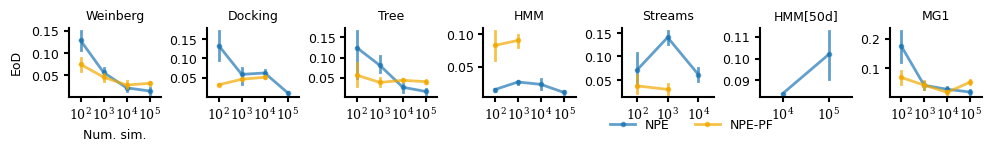

In [10]:
# tasks=["gaussian_mixture", "two_moons", "slcp", "gaussian_linear", "gaussian_linear_uniform", "gaussian_linear", "sir", "bernoulli_glm", "bernoulli_glm_raw", "lotka_volterra"]

methods = ["npe", "filtered_tabpfn"]

with use_style("pyloric"):
    fig, axes = multi_plot(
        "../../main_results/sbibm_newtasks",
        "task",
        "metric",
        partial(plot_metric_by_num_simulations, hue="method"),
        verbose=False,
        metric="sbc",
        method=methods,
        figsize_per_col=1.4,
        figsize_per_row=1.4,
        color_map=DEFAULT_COLORS,
        hue="method",
        # y_lims=(0.5, 1.03),
        legend_bbox_to_anchor=(0.7, 0.02),
    )

    axes[0, 0].set_ylabel("EoD", x=-0.5)

    for ax in axes[0, 1:]:
        pass
        # ax.set_yticklabels([])
        # ax.set_xticklabels([])

    axes[0, 0].set_xlabel("Num. sim.")
    for ax in axes[0, 1:]:
        ax.set_xlabel("")

    # fig.savefig("fig2_amortized.svg", bbox_inches="tight", transparent=True)

(metric=='c2st')
1.05
(3.1500000000000004, 1.2)
(task=='nonlinear_gaussian_tree') & (metric=='c2st')
nonlinear_gaussian_tree
(task=='nonlinear_marcov_chain_long') & (metric=='c2st')


/weka/macke/mgloeckler90/tabpfn_sbi/tabpfn_sbi/utils/data_utils.py:267: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["value"] = df.apply(
/weka/macke/mgloeckler90/tabpfn_sbi/tabpfn_sbi/utils/data_utils.py:267: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["value"] = df.apply(
/weka/macke/mgloeckler90/tabpfn_sbi/tabpfn_sbi/utils/plot_utils.py:217: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
/weka/

nonlinear_marcov_chain_long
(task=='nonlinear_marcov_chain') & (metric=='c2st')
nonlinear_marcov_chain


/weka/macke/mgloeckler90/tabpfn_sbi/tabpfn_sbi/utils/plot_utils.py:217: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
/weka/macke/mgloeckler90/tabpfn_sbi/tabpfn_sbi/utils/data_utils.py:267: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["value"] = df.apply(
/weka/macke/mgloeckler90/tabpfn_sbi/tabpfn_sbi/utils/plot_utils.py:217: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


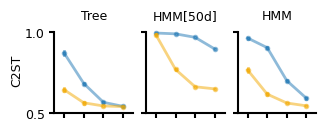

In [11]:
with use_style("pyloric"):
    fig, axes = multi_plot(
        "../../main_results/sbibm_newtasks",
        "task",
        "metric",
        partial(plot_metric_by_num_simulations, hue="method", alpha=0.5),
        verbose=False,
        metric="c2st",
        figsize_per_col=1.05,
        figsize_per_row=1.2,
        color_map=DEFAULT_COLORS,
        hue="method",
        fig_legend=False,
        y_lims=(0.5, 1.03),
    )
    for ax in axes[0, 1:]:
        ax.set_yticklabels([])

    for ax in axes[0, 0:]:
        ax.set_xticklabels([])
        ax.set_xlabel("")

    # turn off the legend
    axes[0, 0].legend().remove()

    for ax in axes[0, 0:]:
        ax.spines["left"].set_bounds(0.5, 1)

    axes[0, 0].set_ylabel("C2ST", x=-0.4)
    # fig.savefig("fig2_amortized_extended.svg", bbox_inches="tight", transparent=True)